# MNIST
## 07. Decision Tree

In [1]:
from infdsa_mnist import dataset_loader, detr_calculations, detr_output
from IPython.display import display

(train_data, test_data) = dataset_loader.load_mnist()
x_train, y_train = train_data
x_test, y_test = test_data

include_train = True
include_test = False

x_data, y_data = dataset_loader.combine_data(x_train, y_train, x_test, y_test, include_train, include_test)

img = x_data[0]
label = y_data[0]
img_norm = dataset_loader.normalize_one(img)
display(label)

np.uint8(5)

Modern machine learning often relies on complex models and algorithms. These algorithms can be imported from external libraries, reducing the need to make the algorithm from scratch. However, this can make it more difficult for us to understand how the algorithm works and what its limitations are. It also reduces the ability to optimize the algorithm for specific hardware or use cases. To help us understand how the algorithm of decision trees works, we will implement it from scratch in this notebook. Therefore, we will pose the following question: **How can we build a decision tree model from scratch that can balance accuracy and extreme hardware constraints?**

To successfully build this model and answer our question, we will work under extreme constraints:
- No external ML libraries
- Embedded system with the following specifications:
    - Memory: 256 KB
    - Storage: 1 MB
    - GPU: None

We will break down our approach into three parts:
1. How can we extract meaningful features from raw pixels efficiently enough for an embedded system?
2. How does the complexity (depth) of a decision tree affect its ability to learn versus to memorize?
3. How would our decision tree model perform on the MysteryDevice?

First, we will address feature extraction by defining a set of five simple features that try to capture the characteristics of handwritten digits without relying on heavy computations.

## Features
To create a decision tree, we need to define features that will be used to split the data. These features should be simple, but they should ideally also capture the most important characteristics of the digits that can help us distinguish them from one another. We will implement the following five features:
1. **Dark pixels**: The percentage of dark pixels in the image. This can help us distinguish digits with more filled areas, such as '8' and '9,' from digits with fewer filled areas, such as '1' and '7.'
2. **Symmetry**: The degree of symmetry in the image. Some digits are generally more symmetrical than others. This can help us distinguish '0's from '2's, which can have similar pixel intensities.
3. **Center point**: The average pixel intensity around the center point of the image. Some digits, like '1' and '8,' tend to have a dense concentration of high pixel intensities around the center point, while other digits, like '0,' may not even have a single pixel with high intensity around the center point.
4. **Aspect ratio**: The ratio of the width and height of the bounding box around the digit. This can help us map out the overall shape of digits, which can be useful for distinguishing between digits with similar pixel intensities but different shapes.
5. **Pixel intensity per region**: The average pixel intensity in the top left, top right, bottom left, and bottom right regions of the image. This can help us capture the distribution of pixel intensities across different regions of the image, which can be useful for distinguishing between digits with similar overall pixel intensities but different distributions of pixel intensities across the image.

### 1. Pixel Intensity
The first feature we will implement is the average pixel intensity of the image. This feature can help us distinguish '8's from lighter digits like '1' and '7.' To calculate this feature, we will first need to flatten the images from their original 2D format into a 1D array. Then, we will calculate the average pixel intensity for each image by taking the mean of the pixel values in the flattened array. This will give us a single value for each image that represents its average pixel intensity.

In [2]:
img_flat = dataset_loader.flatten_one(img_norm)

pixel_intensity_feature = detr_calculations.average_pixel_intensity(img_flat)
display(pixel_intensity_feature)

0.13768007202881152

### 2. Symmetry
The second feature we will implement is the degree of symmetry in the image. '0's are generally more symmetrical than '2's, which can have similar pixel intensities. To calculate this feature, we will first need to calculate the horizontal and vertical symmetry of the image. To do this, we must first filter out the pixels that aren't part of the digit. Then, we will compare the pixel values on either side of the respective axes, For horizontal symmetry, we will compare the left and right halves of the image. For vertical symmetry, we will compare the top and bottom halves of the image. We can calculate the degree of symmetry by taking the absolute difference between the pixel values on either side of the axis and then averaging these differences across all pixels in the image. This will give us a single value for each image that represents its degree of symmetry.

In [3]:
symmetry_feature = detr_calculations.symmetry(img_norm)
display(symmetry_feature)

0.6572156862745098

### 3. Center Point
The third feature we will implement is the average pixel intensity around the center point of the image. Unlike simple pixel intensity features, this will zoom in on the center point to determine how the center plays a role in the digit. To calculate this, we first need to identify the center point of the image. Since MNIST dataset images are 28x28 pixels, the center point is not a perfect match with a single pixel. Because of this, we will define a 2x2 region around the "perfect center" to be the center point, and we will define a balanced 4x4 region around the center point, to capture how the center point affects the digit.
By averaging the pixel intensities in the balanced 4x4 region around the center point, we can get a more accurate representation of the center point's role in the digit. This feature will help us distinguish between digits that have similar overall pixel intensities but different distributions of pixel intensities around the center point.

In [4]:
center_point_feature = detr_calculations.center_point_concentration(img_norm)
display(center_point_feature)

0.48504901960784313

### 4. Aspect Ratio
The fourth feature we will implement is the aspect ratio of the bounding box around the digit. This feature can help us map out the overall shape of digits, which can be useful for distinguishing between digits with similar pixel intensities but different shapes. To calculate this feature, we will first need to identify the bounding box around the digit in the image. We can do this by finding the first and last pixels with a value above a certain threshold in both the horizontal and vertical directions. Once we have the coordinates of the bounding box, we can calculate its width and height. The aspect ratio can then be calculated as the width divided by the height. This will give us a single value for each image that represents its aspect ratio.

In [5]:
aspect_ratio_feature = detr_calculations.aspect_ratio(img_norm)
display(aspect_ratio_feature)

1.0

### 5. Pixel Intensity per Region
The fifth feature we will implement is the average pixel intensity in the top left, top right, bottom left, and bottom right regions of the image. This feature can help us capture the distribution of pixel intensities across different regions of the image, which can be useful for distinguishing between digits with similar overall pixel intensities but different distributions of pixel intensities across the image. To calculate this feature, we will first need to divide the image into four equal regions: top left, top right, bottom left, and bottom right. We can do this by splitting the image into two halves horizontally and two halves vertically. Then, we will calculate the average pixel intensity for each of these regions by taking the mean of the pixel values in each region. This will give us four values for each image that represent the average pixel intensity in each of the four regions. These will be saved to be used as separate checks in the decision tree.
> NOTE: Even though this feature is listed as one feature, in practice, this will yield four separate features, one for each region. This is because we will want to use the spatial data independently in the decision tree. For example, if the decision tree only needs the top left corner to make a decision after a certain depth, it would be inefficient to give the decision tree the average pixel intensity of all regions. This makes the decision tree more spatially aware and could yield more accurate results.

In [6]:
region_intensity_feature = detr_calculations.region_intensities(img_norm)
display(region_intensity_feature)

{'tl_intensity': 0.1338535414165666,
 'tr_intensity': 0.12927170868347337,
 'bl_intensity': 0.1360344137655062,
 'br_intensity': 0.1515606242496999}

## Creating the Subset
Now that we have defined our features, we can create a subset of the data to work with. We will select a small number of images from the dataset and calculate the values of these features for each image. We will then save these features, alongside the image itself. This will allow us to build the decision tree based on these features.

In [7]:
subset = detr_calculations.create_subset(x_data, y_data, subset_size=300)

display(subset["images"][0])
display(subset["labels"][0])
display(subset["features"][0])

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

np.uint8(5)

array([0.13768007, 0.6572157 , 0.485049  , 1.        , 0.13385354,
       0.12927172, 0.13603441, 0.15156062], dtype=float32)

The subset we have created will contain 300 images from the dataset, along with their corresponding labels and the calculated features. These are set up in a **dictionary** data structure, with three keys: "features," "images," and "labels." Every value is a NumPy array, with the following setup:
- _Images_: A 2D array, where a single entry represents a single image. Each entry is a 28x28 NumPy array representing the pixel values of the image. It is not normalized, as the normalization would increase the RAM usage. More on that in the upcoming section.
- _Labels_: A 1D array of the corresponding labels for each image. Each entry is a single integer, representing the label of the image.
- _Features_: A 1D array of the feature values for an image.

#### Note on Data Structures
The decision to use a dictionary to store the data was made to ensure the data is organized and easily accessible. By using a dictionary, we can easily access all related information for a given image without having to manage multiple separate arrays or data structures. This approach also allows us to expand what information we store for each image in the future without needing to redesign the data storage.
The choice to use NumPy arrays for storing the images, labels, and features was made to reduce the overhead associated with native Python data structures. NumPy arrays are more memory-efficient, given we only need to store the same type of data per array. Since RAM usage is our primary concern, using NumPy arrays allows us to be more efficient with our memory usage while still providing fast access to the data.

To further reduce RAM usage, we have decided not to normalize the images in the subset. This choice was made based on this reasoning:
- Not normalized, the dataset would be stored as unsigned 8-bit integers (uint8).
- Normalized, the dataset would be stored as 32-bit floating-point numbers (float32).
Since each pixel value in the original dataset is already uint8, we will not benefit from normalizing the images to build the decision tree. We will still use normalized data for the actual calculations, but we will not store the normalized images in the subset to save RAM. This way, the features have access to the normalized pixel values for their calculations, whilst the subset does not concern itself with a data format that takes up more RAM than necessary.

## Building the Decision Tree
Now that we have our subset of data with the calculated features, we can proceed to build the decision tree. We have designed a simple `build_tree` function that recursively constructs a decision tree based on whichever feature best separates the labels. There are several rules to follow when building the tree:
Base cases:
- If all labels are the same, or if the maximum depth is reached, a leaf node will be returned with the majority label.
- If all labels are empty, `None` will be returned.

Recursive case:
For each of the features, this is what happens:
1. A threshold is determined. This is done by calculating the mean value of the feature across all images in the subset.
2. The data is split into two subsets (`left` and `right`) based on whether the feature value is less than, or equal or greater than the threshold.
3. A score is computed. This is done by adding the count of the majority label in the left subset and the count of the majority label in the right subset.
The score is an estimate of the split's purity. A higher score means the split is putting samples on the same side that "agree" with each other, which is desired. The feature with the highest score is selected as the best feature to split on.\n
Once the split is found:
4. The `features` and `labels` are divided into the `left` and `right` subsets, based where on the threshold the feature values fall.
5. The `build_tree` function is called recursively on each subset.
6. A decision node is returned containing the feature index, threshold, and the left and right subtrees.

A calculated limitation is that it always calculates the threshold based on the mean value of the feature across all images in the subset. The split score does not account for class imbalance, which can lead to suboptimal splits if the dataset is imbalanced. This means that an unbalanced split (190 `left`, 10 `right`) could score higher than an informative balanced split (100 `left`, 100 `right`). This is a trade-off we have made to try to limit the complexity of the algorithm.

In [8]:
decision_tree = detr_calculations.build_tree(subset["features"], subset["labels"])

## Testing the Decision Tree
To see if our decision tree is working, we can test it on completely new data. We will take ten new images from the testing set, extract their features, and use the `predict` function to get the predicted labels from the decision tree. We will then compare these predicted labels to the actual labels to evaluate the performance of our decision tree.
We will test the decision tree a few times, each time with a different depth. This will allow us to see how the depth of the tree affects its performance. We will show the number of correct predictions, as well as which images were correctly classified and which were not. This will give us insight into how well our decision tree is performing and where it may be making mistakes and why.

,Depth 1,Depth 2,Depth 3,Depth 4,Depth 5,Depth 6,Depth 7,Depth 8,Image Accuracy
Img 1 (Actual: 7),WRONG (0),RIGHT (7),RIGHT (7),RIGHT (7),WRONG (0),WRONG (0),WRONG (2),WRONG (4),37%
Img 2 (Actual: 2),WRONG (0),WRONG (0),WRONG (6),WRONG (4),WRONG (0),WRONG (0),WRONG (4),WRONG (4),0%
Img 3 (Actual: 1),RIGHT (1),RIGHT (1),RIGHT (1),RIGHT (1),RIGHT (1),RIGHT (1),RIGHT (1),RIGHT (1),100%
Img 4 (Actual: 0),RIGHT (0),RIGHT (0),RIGHT (0),RIGHT (0),RIGHT (0),RIGHT (0),RIGHT (0),WRONG (2),87%
Img 5 (Actual: 4),WRONG (0),WRONG (7),WRONG (7),WRONG (7),WRONG (7),RIGHT (4),WRONG (7),WRONG (6),12%
Img 6 (Actual: 1),RIGHT (1),RIGHT (1),RIGHT (1),RIGHT (1),RIGHT (1),RIGHT (1),RIGHT (1),RIGHT (1),100%
Img 7 (Actual: 4),WRONG (1),WRONG (1),WRONG (9),WRONG (9),WRONG (9),WRONG (9),WRONG (9),WRONG (9),0%
Img 8 (Actual: 9),WRONG (1),WRONG (1),RIGHT (9),WRONG (1),WRONG (3),WRONG (8),WRONG (4),WRONG (4),12%
Img 9 (Actual: 5),WRONG (0),WRONG (0),WRONG (0),WRONG (0),WRONG (0),WRONG (0),WRONG (0),WRONG (0),0%
Img 10 (Actual: 9),WRONG (1),WRONG (3),WRONG (3),WRONG (3),WRONG (3),WRONG (3),WRONG (3),WRONG (3),0%


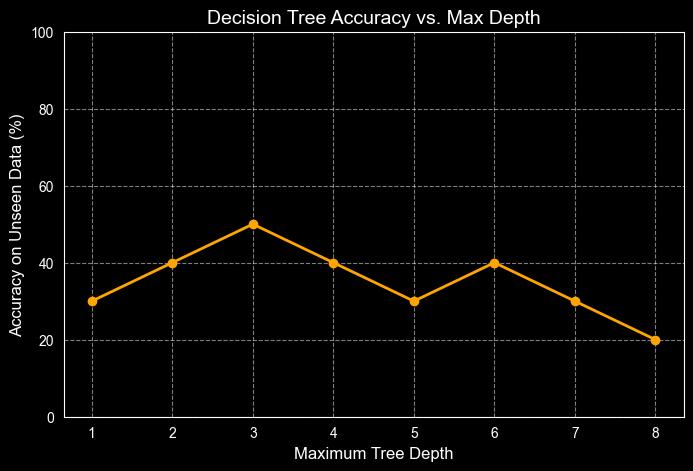

In [9]:
num_samples = 10
test_images = x_test[:num_samples]
test_labels = y_test[:num_samples]

depth_results = []
accuracy_results = []
all_predictions = {}

for current_depth in range(1, 9):
    experimental_tree = detr_calculations.build_tree(
        subset["features"],
        subset["labels"],
        max_depth=current_depth
    )

    correct, predictions = detr_calculations.test_tree(
        experimental_tree,
        test_images,
        test_labels,
        num_samples=num_samples
    )

    accuracy_pct = int((correct / num_samples) * 100)

    depth_results.append(current_depth)
    accuracy_results.append(accuracy_pct)
    all_predictions[f"Depth {current_depth}"] = predictions

detr_output.plot_depth_experiment(depth_results, accuracy_results, all_predictions, test_labels)

### Analyzing the Depth Experiment

As we can see from the results, the accuracy leaves something to be desired. 50% accuracy might not seem like an incredible score, though we must keep into consideration that this is still four times better than random guessing (10%) whilst the dataset and features are relatively simple. This means that our decision tree is successfully recognizing patterns in the data.

More importantly, we can see that the accuracy does not necessarily increase with depth. In fact, the accuracy is highest at a depth of 3, at 50% accuracy. This lets us draw boundaries between depths:
- Underfitting (Depth 1): The model is too simple. It only gets to ask a single question, and therefore chooses between just two classes – 0 and 1. It performs poorly (30%).
- Sweet Spot (Depths 2 and 3): The model has enough depth to separate the big differences without getting too specific on edge cases. It generalizes well, reaching our peak accuracy of 50%. A depth of 2 is also considered a sweet spot here, as it reduces the number of questions the model needs to ask without sacrificing much accuracy.
- Overfitting (Depths 4 and above): The model starts to struggle. Because we give the model only a small subset of the data (300 images), a deep tree stops learning general shapes and starts focusing on the details. This means that flaws get memorized, leading to worse classification accuracy.

This proves that for our embedded system, a shallower tree isn't just better for hardware reasons, but also for accuracy. The balance of accuracy and hardware constraints is crucial, and in this case, a depth of 3 seems to be the optimal choice for our decision tree model.

## Embedded System Validation
We have mentioned throughout the notebook that one of our main goals is to create a decision tree that can run on an embedded system with limited resources. To verifiably prove that our model fits within these constraints, we will calculate the exact memory footprint of our dataset and estimate the size of our trained decision tree. Because we strategically stored our images as unsigned 8-bit integers (`uint8`) and our features as 32-bit floats (`float32`), we expect our memory usage to be highly optimized.

Below, we will assume that the _optimal tree_ is the tree built with a maximum depth of 3, as this is the tree that yielded the highest accuracy in our testing. It would be possible to build a smaller tree with a maximum depth of 2. This would lower the computational load on the system, but it would also reduce the accuracy of the model.

In [10]:
optimal_tree = detr_calculations.build_tree(subset["features"], subset["labels"], max_depth=3)
dataset_memory_usage = detr_calculations.calculate_system_metrics(subset, optimal_tree)

detr_output.plot_systems_report(dataset_memory_usage)

Category,Metric,Usage,Limit,Status
RAM,Dataset Footprint,239.36 KB,-,-
RAM,Tree Footprint (15 nodes),2.34 KB,-,-
RAM,Total Peak RAM,241.70 KB,256.00 KB,SUCCESS
Storage,Serialized Model,0.75 KB,-,-
Storage,Dataset Binary,239.36 KB,-,-
Storage,Total Disk Usage,240.10 KB,1024.00 KB,SUCCESS
Hardware,Compute Targeted,"CPU Only (NumPy, built-ins)",No GPU,SUCCESS


From the results, we can see that, with a depth of 3, our decision tree has a RAM usage of approximately 240 KB, which is well within our 256 KB RAM constraint. The storage usage of the decision tree is similarly around 240 KB, which is easily within our 1 MB storage constraint. This means that our decision tree can indeed comfortably run on an embedded system with the specified constraints. Furthermore, we can draw a few more conclusions from the results:
- The dataset takes up a significant portion of both the RAM and the storage, which highlights the importance of optimizing how we store our data. By using `uint8` for the images and `float32` for the features, we were able to keep our memory usage low enough to fit within the constraints, and to keep more than enough memory available for the necessary computations.
- The storage usage is heavily underutilized. In notebook `05_data_quality_difficulties`, we used a Random Forest model to create a heatmap and a bar plot to analyze the most challenging digit classes in the dataset. If we were to expand upon this exercise to fully use every aspect of the MysteryDevice, we could potentially train four trees with different subsets and features and still have enough storage to spare. This could allow us to create a model that is more robust and accurate, as different trees could capture different patterns and collaborate with one another to make predictions. However, for the sake of simplicity, we have chosen to acknowledge the possibility without implementing it right away.